# 04 Zahlenerkennung

# Erkennung von Zahlen

Überwachtes Lernen wird im Folgenden anhand eines einfachen und anschaulichen Beispiels erläutert: der Erkennung handgeschriebener Ziffern.
Zu diesem Zweck wird zunächst ein eigener Trainingsdatensatz aus handgeschriebenen Zahlen erstellt. Ausgangspunkt sind sortierte Bilddaten der Ziffern von 0 bis 9. Die einzelnen Ziffern werden aus dem Dokument extrahiert, den jeweiligen Zahlenklassen zugeordnet und in Arrays gespeichert.
Um die Datenmenge überschaubar zu halten und den Rechenaufwand zu reduzieren, werden die Bilder der einzelnen Ziffern auf eine einheitliche Größe von 28 × 28 Pixeln skaliert. Für die eigentliche Bilderkennung werden nicht die Farbbilder selbst verwendet. Stattdessen werden die Farbkanäle zunächst in Graustufen umgewandelt und anschließend die Konturen der Ziffern extrahiert.
Diese reduzierte und abstrahierte Darstellung dient schließlich als Eingabe für ein neuronales Netz, das mithilfe der zugehörigen Klassenlabels trainiert wird.

<figure  style="text-align: center;">
    <img src="Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert02.png" alt="Neuron" width = 300>
    <figcaption>Beispiel einer Handschriftprobe von sortierten Zahlen im Raum 0 bis 9</figcaption>
</figure>



## Aufgabe 1: Erstellen von Trainingsdaten

Erstellen Sie ihren eigenen Satz von Trainingsdaten nach dem oben dargestellten Beispiel. Speichern Sie die Datei unter dem Namen 'Zahlen_Handschrift_sortiertXX.png' und senden Sie das Bild an die Kursleitung. Das XX ist dabei eine laufende Nummer (beginnend mit 15). Stimmen Sie sich bezüglich der Nummer mit der Kursleitung ab.

*Hinweis:* 

Achten Sie beim Zahlen schreiben darauf, dass die Zahlen jeweils aus einer zusammenhängenden Linie bestehen. Lücken innerhalb einer Zahl machen das Erkennen der Konturen ungleich aufwändiger. Dies wäre eine schöne Erweiterung nach Abschluss der ersten Zahlenerkennung.

Aus den gesammelten Daten kann nun der Trainingsdatensatz erstellt werden. 

# Einlesen und Sortieren der Trainingsdaten

In [1]:
#| code-fold: true
#| code-summary: "Code anzeigen"


import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import re
import cv2

# Funktion zur numerischen Sortierung der Dateien
def extract_number(filename):
    return int(re.search(r"_sortiert(\d+)", filename).group(1))

# Alle Files einleden, die mit Zahlen_Handschrift_sortiert beginnen und direkt darauf folgend eine Zahl im Namen haben.
liste_daten = glob('Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert*[0-9].png')

# Liste numerisch sortieren und sortierte Liste ausgeben
liste_daten = sorted(liste_daten, key=extract_number)
for el in liste_daten:
    print(el)

Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert01.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert02.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert03.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert04.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert05.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert06.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert07.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert08.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert09.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert10.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert11.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert12.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert13.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert14.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert15.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert16.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert17.p

Im nächsten Schritt werden die einzelnen Zahlen aus den Bildern herausgelesen.

Dazu wir mit der zuvor erstellten Liste der Bilddateien jedes Bild  

1. eingelesen, 
2. in ein Graustufenbild umgewandelt 
3. mit einem Gauß-Filter geglättet, um Bildrauschen zu reduzieren. 

Danach wird eine [adaptive Schwellwertmethode](https://de.wikipedia.org/wiki/Schwellenwertverfahren) angewendet, um ein binäres Bild zu erzeugen, in dem die Ziffern klar vom Hintergrund getrennt sind.

Anschließend werden die Konturen der Ziffern im Bild gesucht. Konturen mit zu kleiner Fläche oder zu geringer Höhe werden verworfen, um Störungen und Rauschen zu eliminieren. Für die verbleibenden Konturen werden rote Rechtecke in das Originalbild eingezeichnet, sodass die erkannten Ziffern visuell kontrolliert werden können.

Die gültigen Konturen werden danach in einer festen Reihenfolge (von oben nach unten und von links nach rechts) sortiert. Für jede erkannte Ziffer wird der entsprechende Bildausschnitt (Region of Interest) ausgeschnitten, auf eine Größe von 28 × 28 Pixeln skaliert und in einer Liste gespeichert. Parallel dazu wird die Anzahl der erkannten Ziffern gezählt und zur Erzeugung der passenden Klassenlabels verwendet.

Am Ende werden alle Bilddaten in ein NumPy-Array überführt und die zugehörigen Zielwerte in einem eindimensionalen Label-Array zusammengefasst, das für das Training eines überwachten Lernverfahrens genutzt werden kann.

Zuvor werden hierzu zwei Hilfsfunktionen definiert, die Funktion **`imshow`** und die Funtion **`sort_contours_grid`**:

Die Funktion **`imshow`** dient zur komfortablen Anzeige von Bildern innerhalb eines Notebooks. Sie überprüft zunächst, ob das Bild ein Farbbild im OpenCV-typischen BGR-Format ist, und wandelt es gegebenenfalls in das RGB-Format um, damit es mit Matplotlib korrekt dargestellt wird. Anschließend wird die Bildgröße dynamisch an das Seitenverhältnis angepasst, das Bild angezeigt, mit einem Titel versehen und die Achsen ausgeblendet. Dadurch lassen sich Bilder unabhängig von ihrer Auflösung übersichtlich visualisieren.

Die Funktion **`sort_contours_grid`** sortiert eine Liste von OpenCV-Konturen in einer logischen Lese-Reihenfolge. Zunächst werden zu jeder Kontur die umschließenden Rechtecke bestimmt. Die Konturen werden dann zuerst nach ihrer vertikalen Position sortiert, sodass sie von oben nach unten angeordnet sind. Anschließend werden die Konturen anhand ihrer y-Koordinate zu Zeilen gruppiert, wobei der Parameter `row_height` bestimmt, ab welchem vertikalen Abstand eine neue Zeile beginnt. Innerhalb jeder Zeile werden die Konturen schließlich von links nach rechts sortiert.

Das Ergebnis ist eine Liste von Konturen, die in der gleichen Reihenfolge angeordnet sind, wie ein Mensch sie beim Lesen eines Gitters oder Dokuments wahrnehmen würde, was insbesondere für die korrekte Zuordnung von Ziffern oder Zeichen zu ihren Labels wichtig ist.



## Hilfsfunktionen definieren

In [2]:
#| code-fold: true
#| code-summary: "Code anzeigen"


def imshow(name, img, size=8):
    import matplotlib.pyplot as plt
    from IPython.display import display
    import cv2

    # Convert BGR to RGB
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img.shape[:2]
    aspect = w / h
    plt.figure(figsize=(size * aspect, size))
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.title(name)
    plt.axis('off')
    #plt.show()

# contours are not sorted, so sort them to assign the correct labels later
def sort_contours_grid(contours, row_height=50):
    # Extract bounding boxes
    bounding_boxes = [cv2.boundingRect(c) for c in contours]

    # Combine contours with their boxes
    contours_with_boxes = list(zip(contours, bounding_boxes))

    # First sort top-to-bottom by y
    contours_with_boxes.sort(key=lambda b: b[1][1])  # b[1][1] = y

    # Group contours into rows based on y
    rows = []
    current_row = []
    last_y = -row_height

    for c, (x, y, w, h) in contours_with_boxes:
        if y - last_y > row_height:
            if current_row:
                rows.append(current_row)
            current_row = [(c, (x, y, w, h))]
            last_y = y
        else:
            current_row.append((c, (x, y, w, h)))
    if current_row:
        rows.append(current_row)

    # Now sort each row left to right
    sorted_contours = []
    for row in rows:
        row.sort(key=lambda b: b[1][0])  # sort by x
        sorted_contours.extend([c for c, _ in row])

    return sorted_contours

## Konturen erkennen

Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert01.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert02.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert03.png
210 21.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert04.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert05.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert06.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert07.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert08.png
210 21.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert09.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert10.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert11.png
210 21.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert12.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert13.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert14.png
210 21.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sort

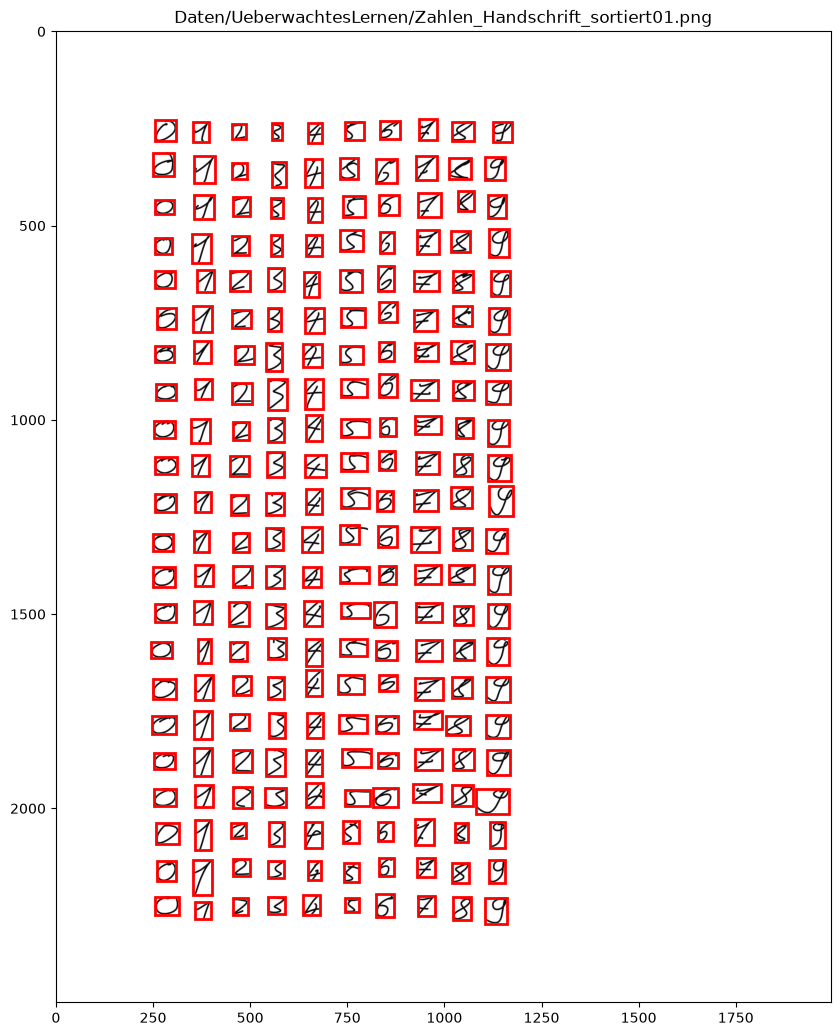

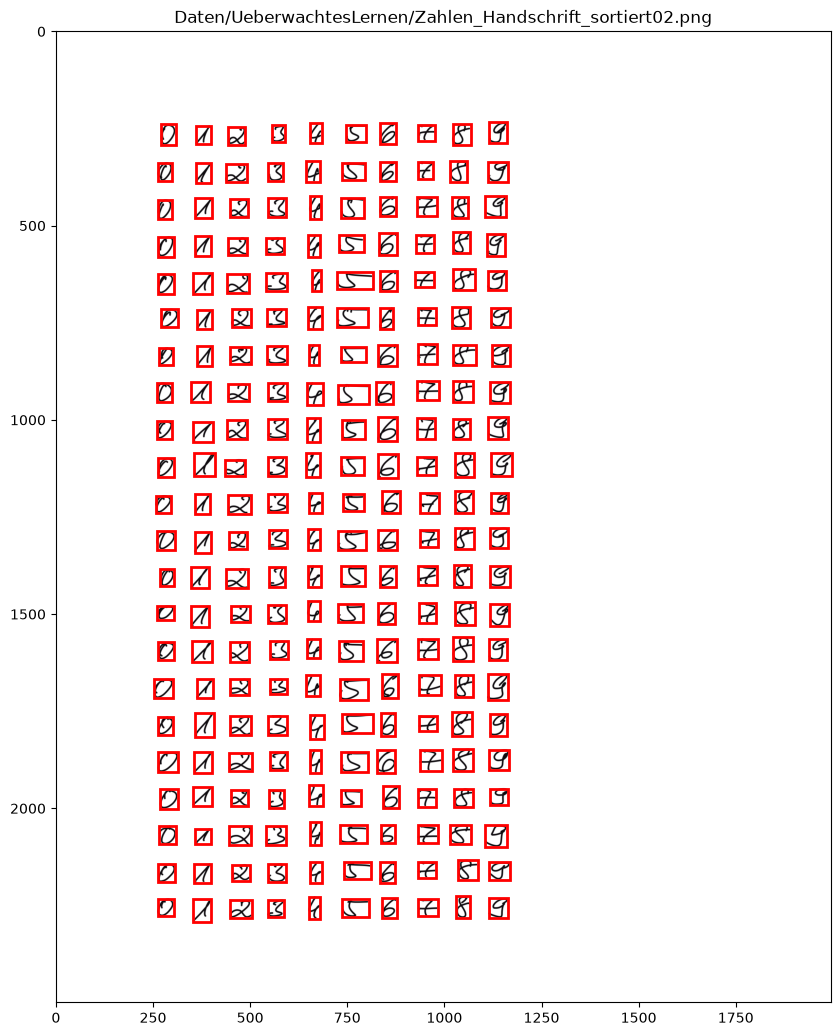

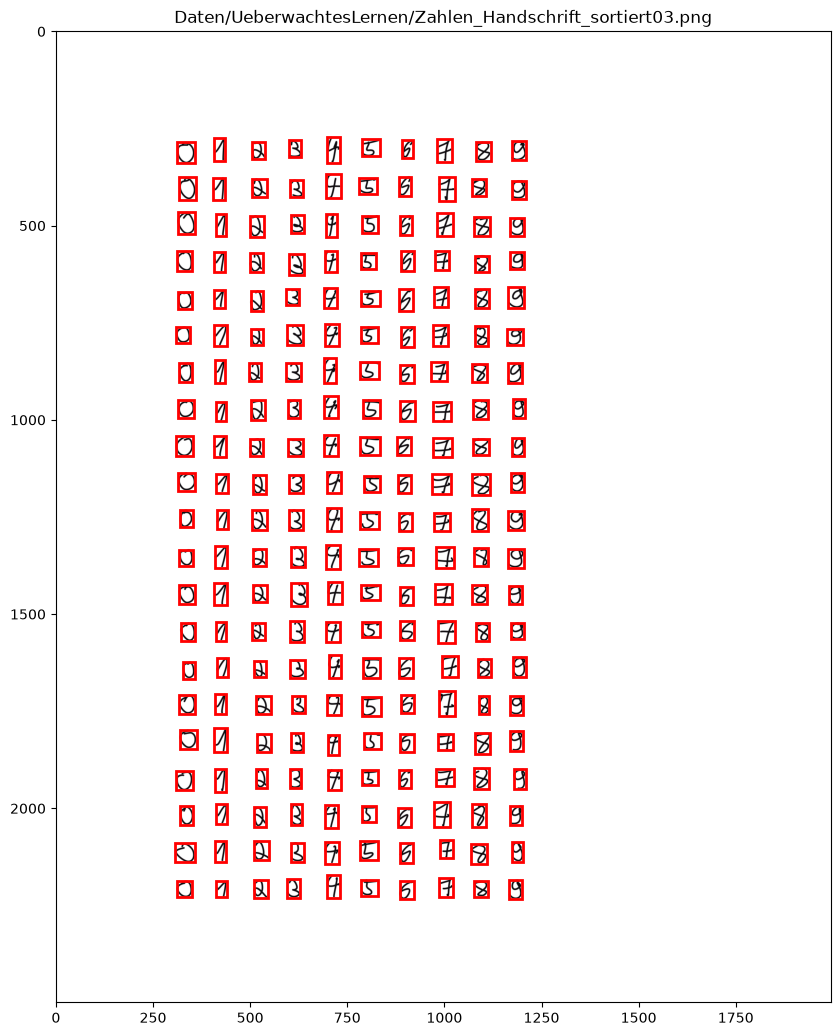

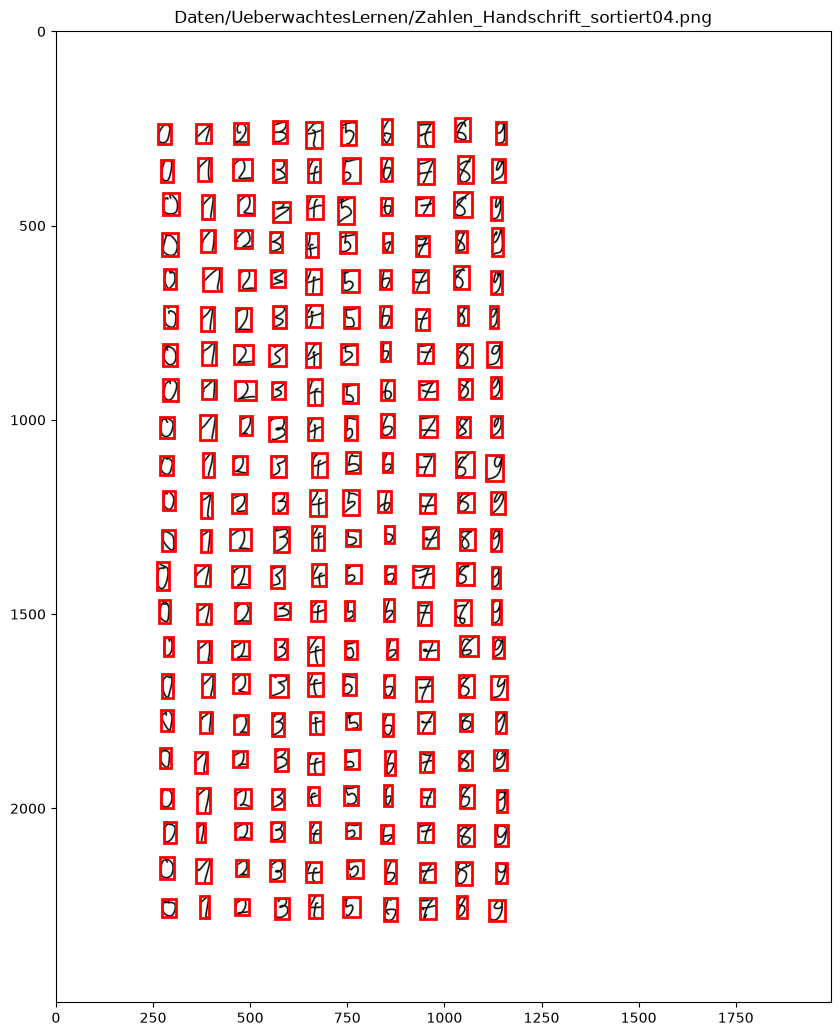

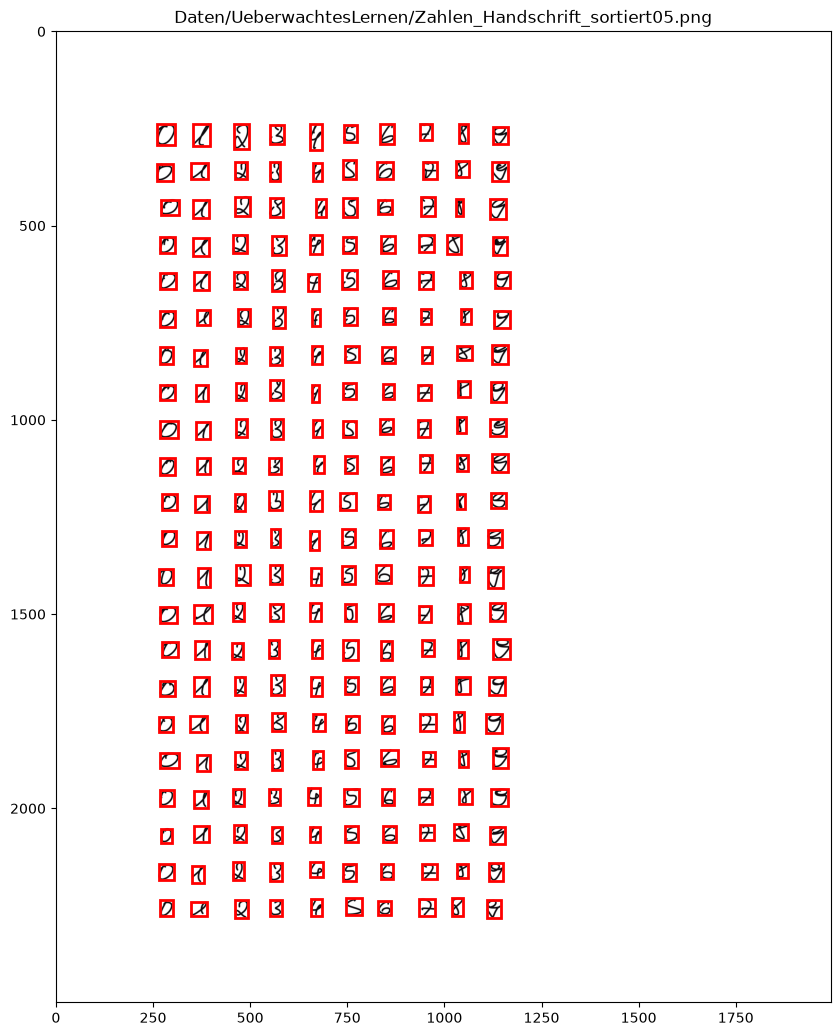

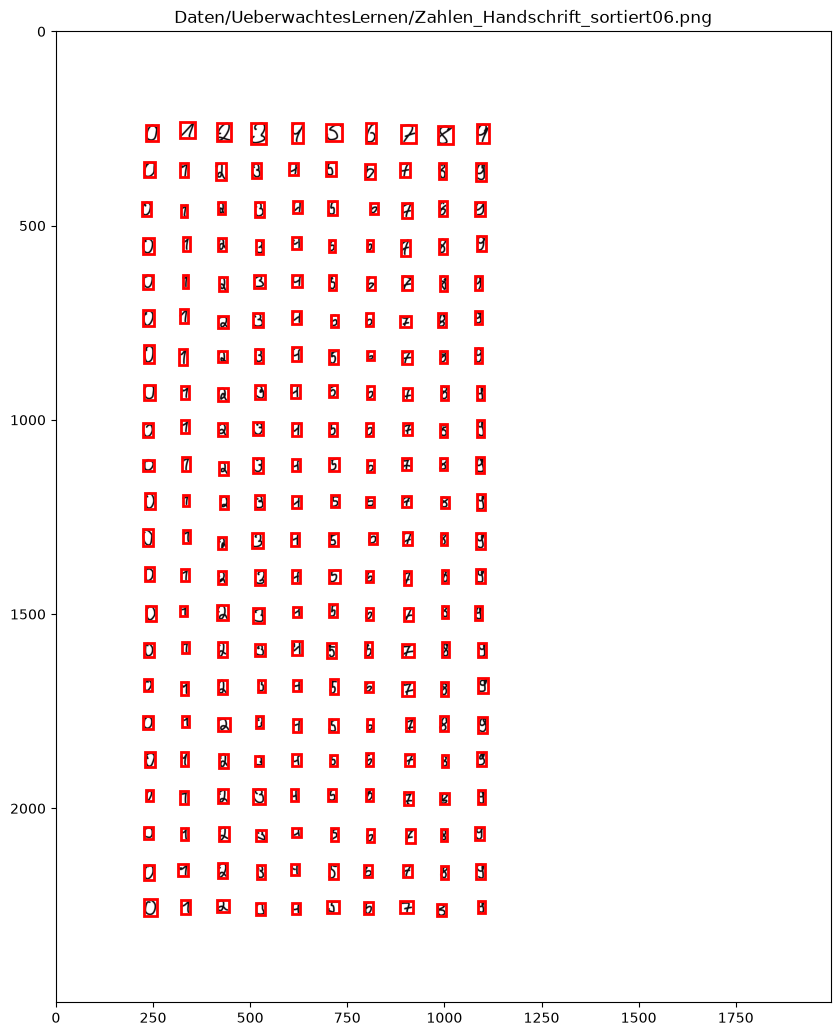

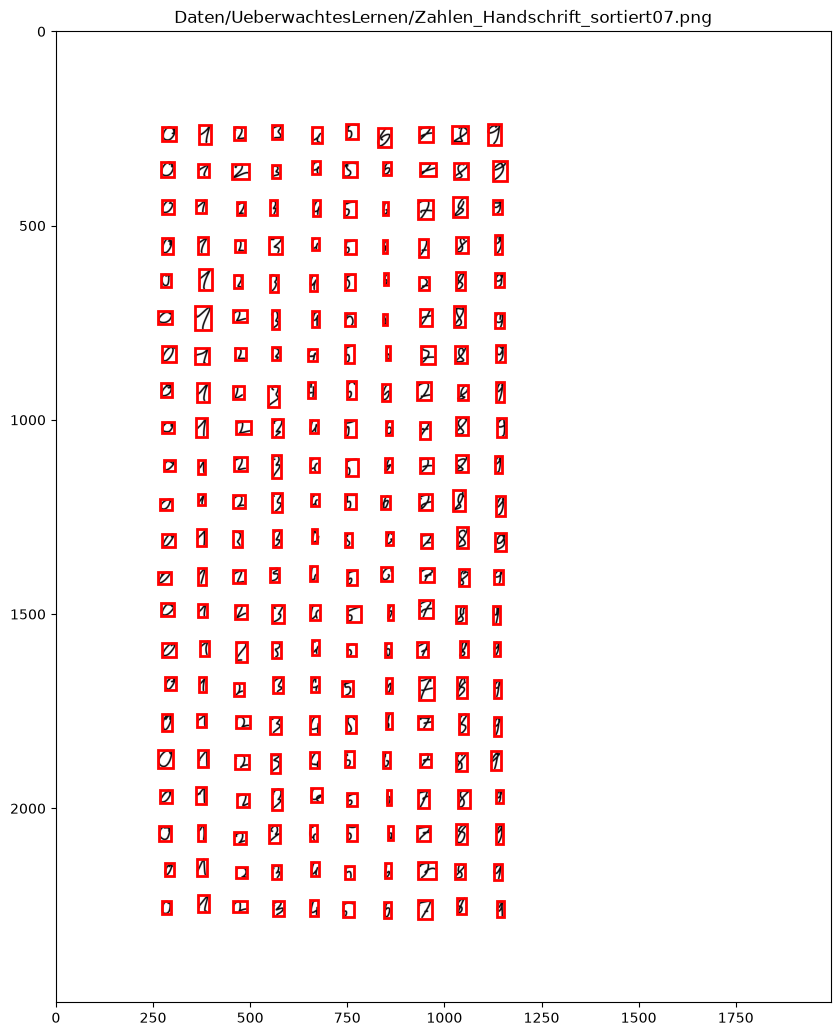

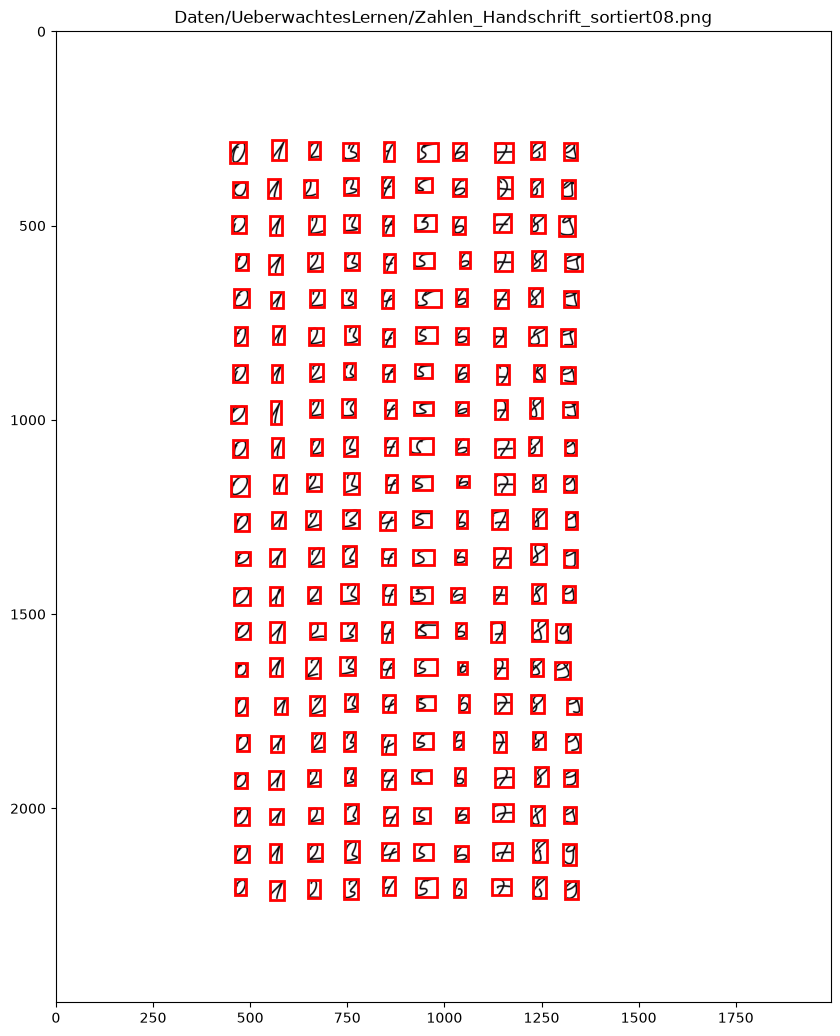

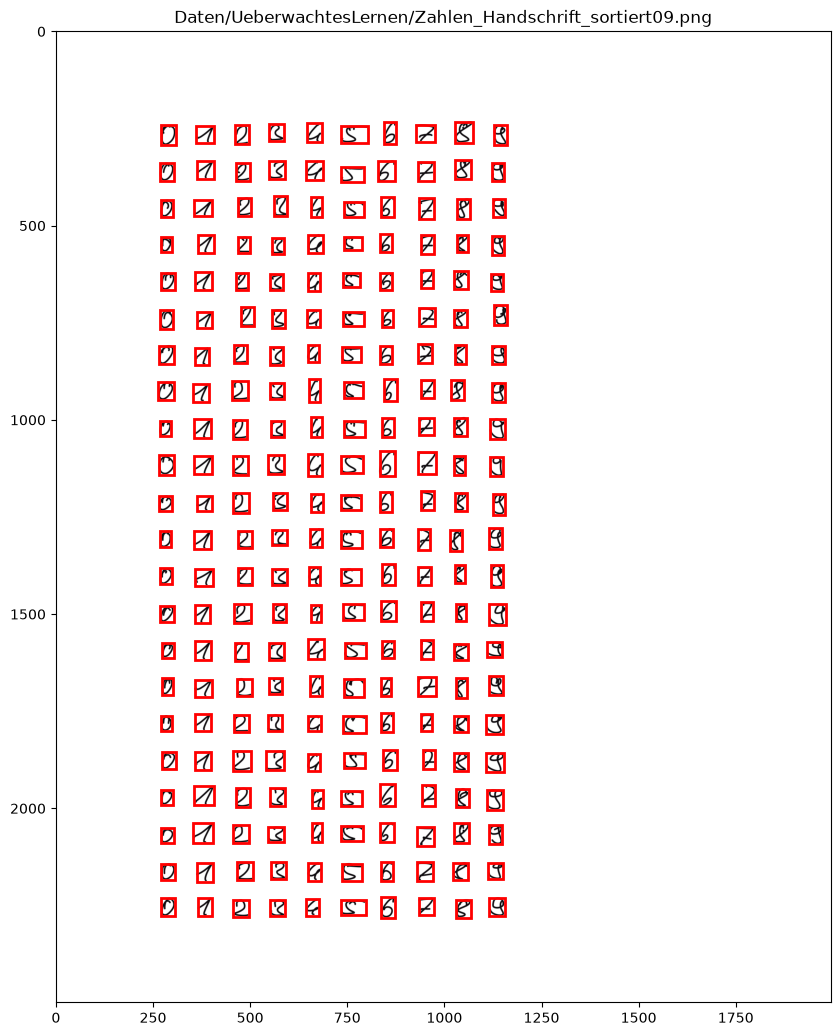

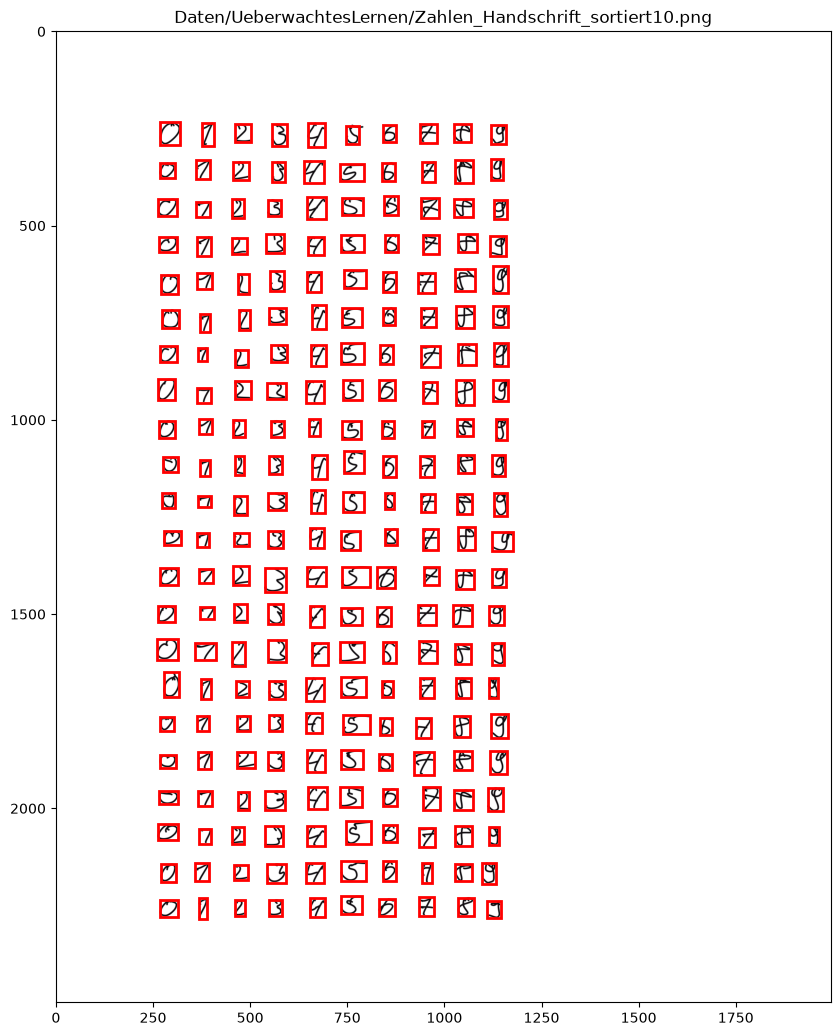

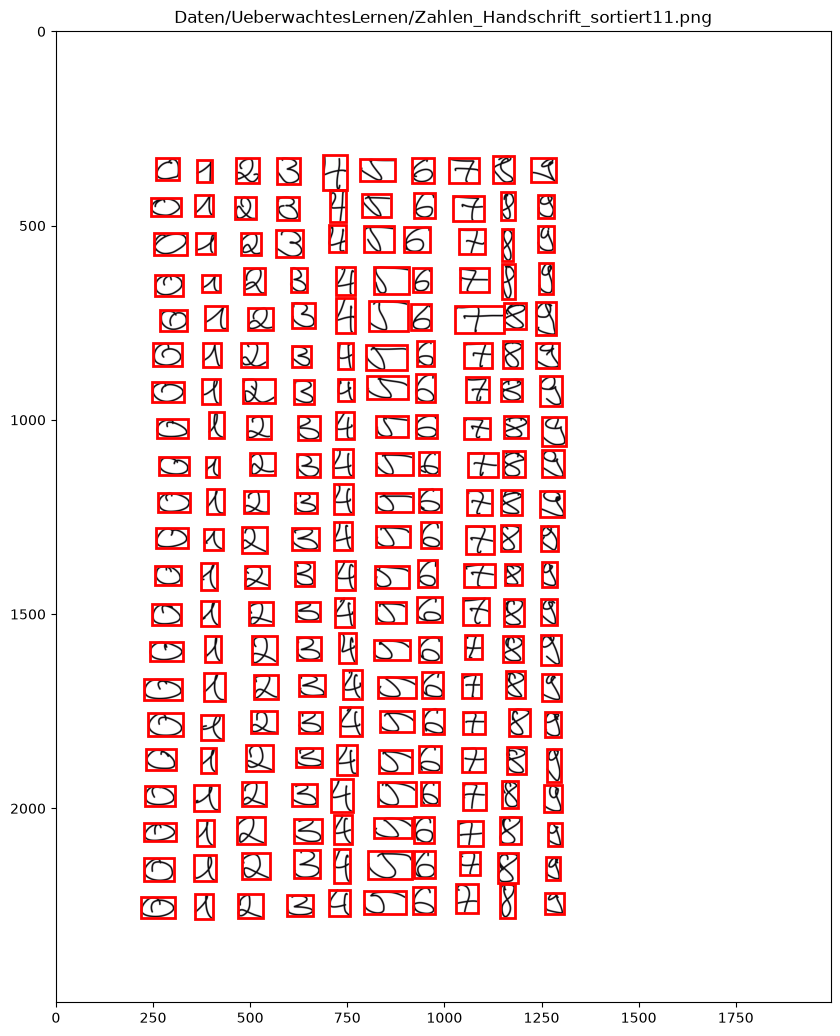

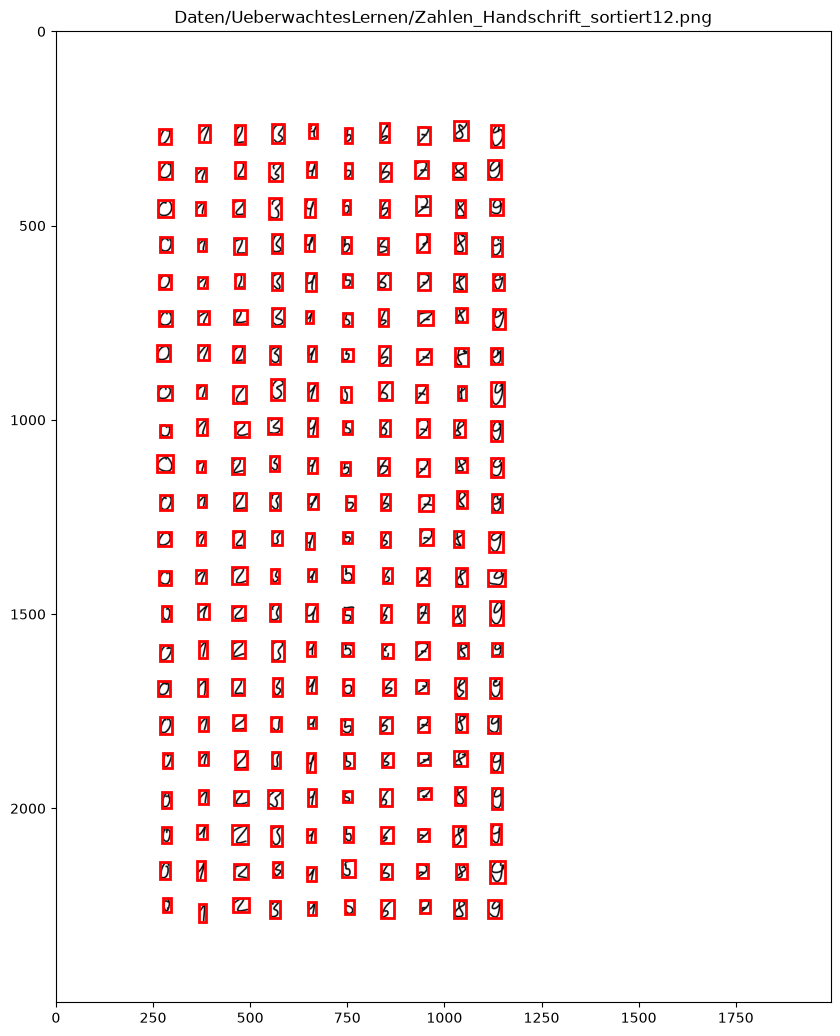

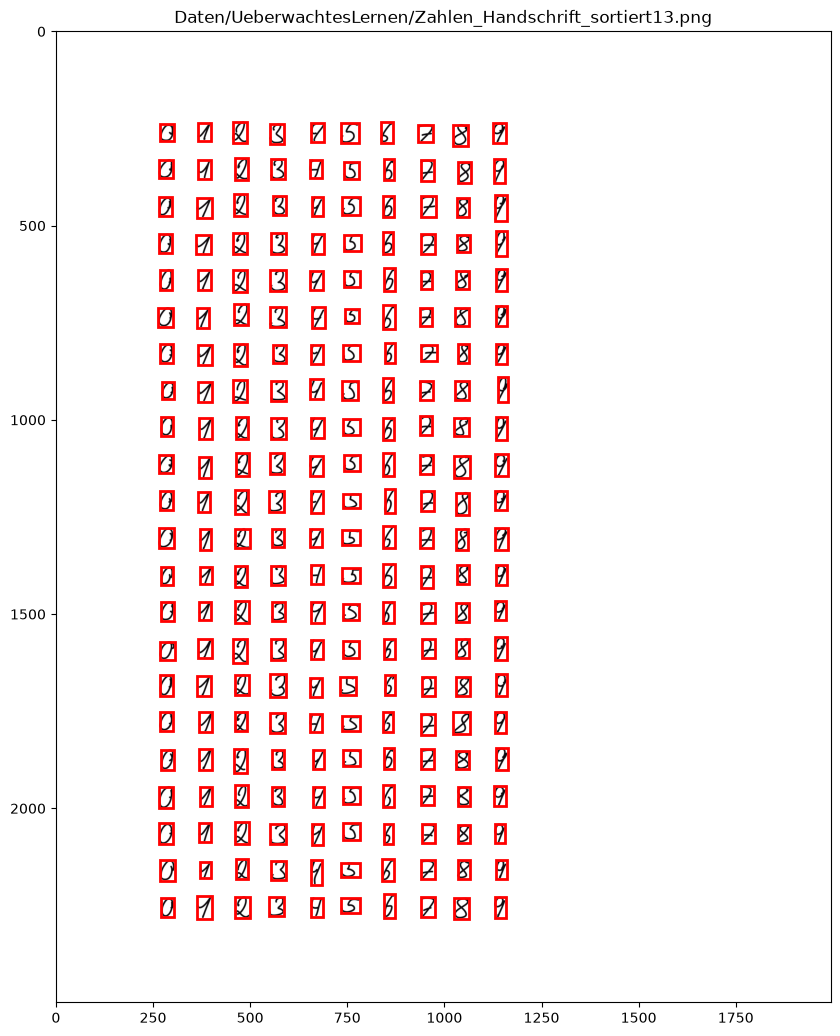

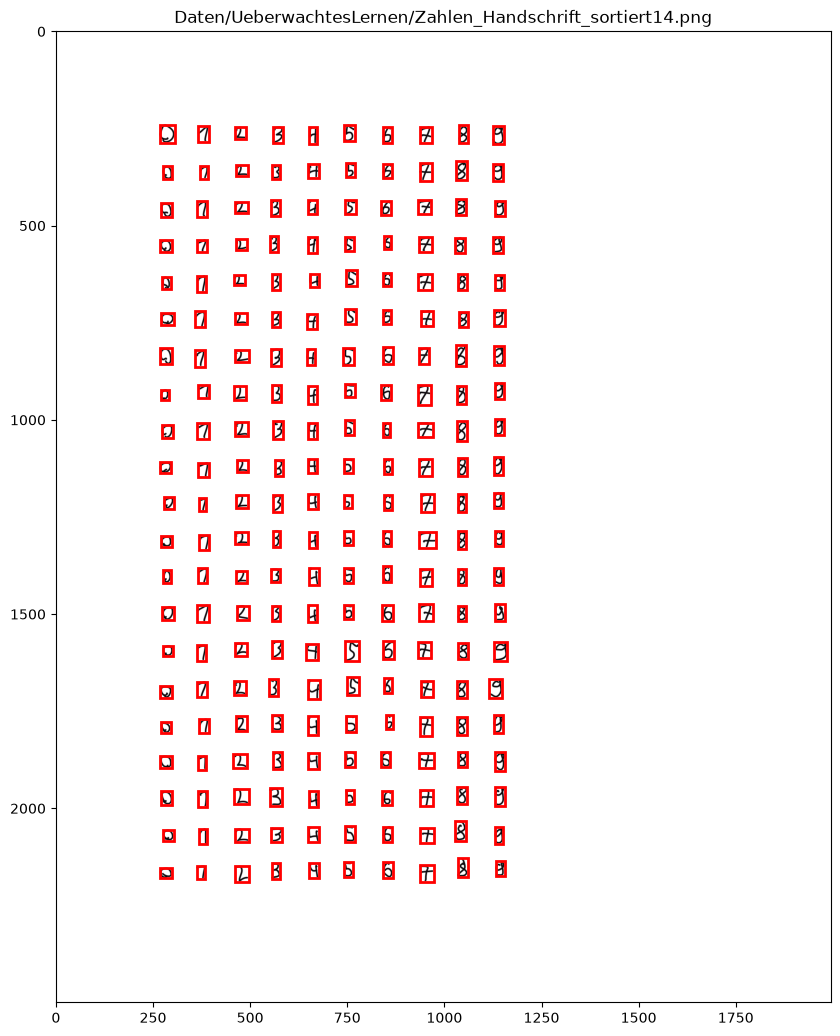

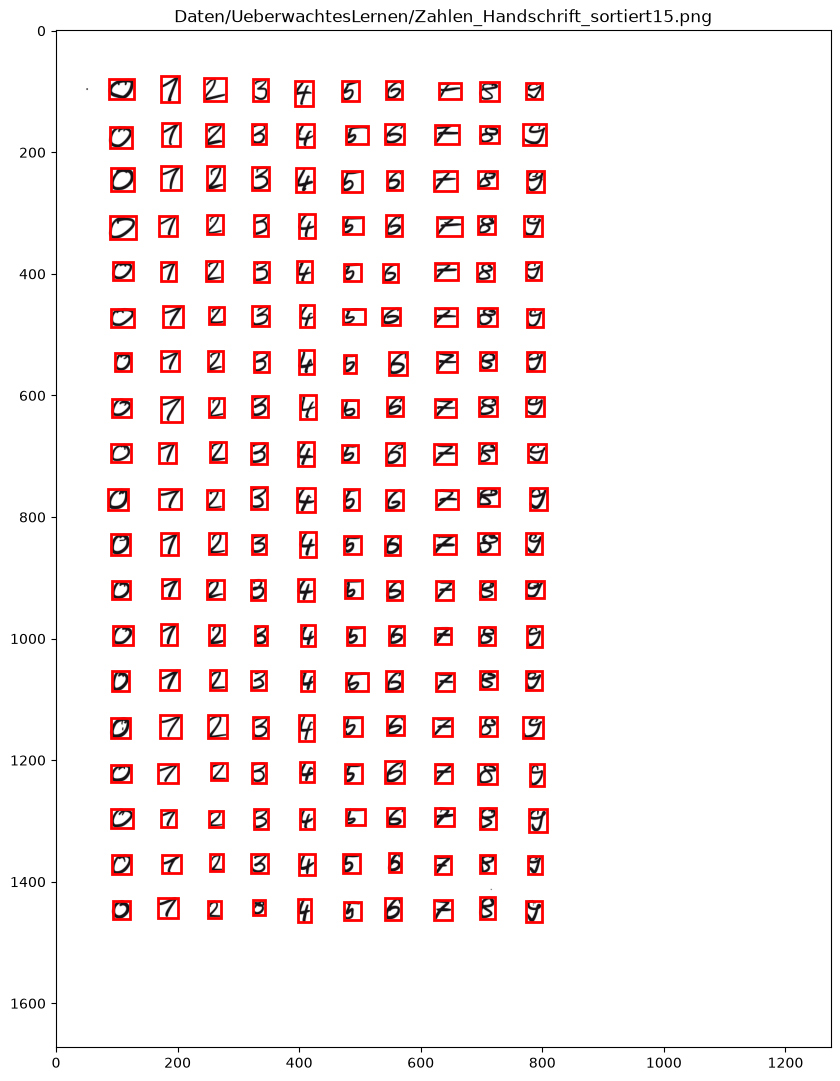

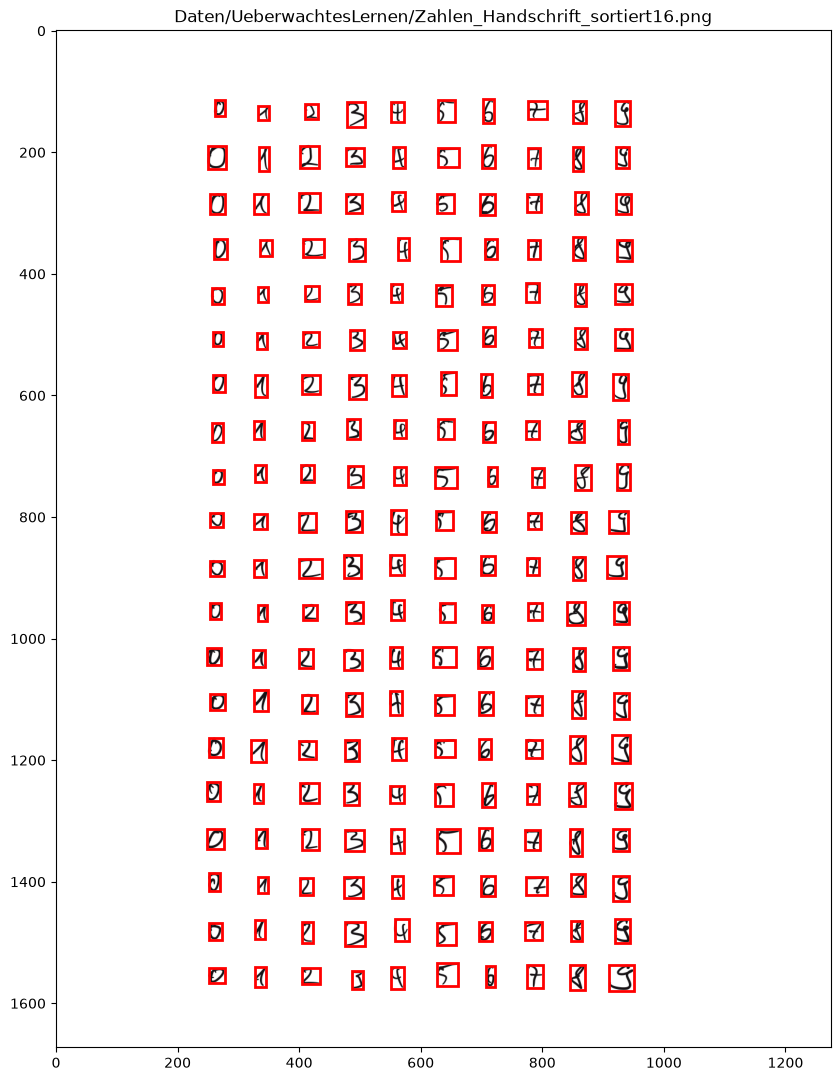

In [3]:
#| code-fold: true
#| code-summary: "Code anzeigen"

contour_height = 22

x_data_list = []
response_list = []

## Für die bessere Übersicht im Skript werden hier nur die ersten zwei Bilder ausgewertet. Wenn alle Bilder ausgewertet werden sollen, kommende Zeile auskommentieren und die alternative for-Schleife reinnehmen.
#for im in liste_daten[:2]:

## Alle Bilder auswerten
for im in liste_daten[:-1]:

    print(im)
    image = cv2.imread(im)

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(5,5),0)
    thresh = cv2.adaptiveThreshold(blur,255,1,1,11,2)

    # find digits in image and create contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    no_digits = 0
    plt.figure(figsize = (10,15))
    plt.imshow(image, cmap='gray')
    plt.title(im)

    # jetzt rotes Viereck um jede Zahl zeichnen
    for cnt in contours:
        if cv2.contourArea(cnt) > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            if h > contour_height:
                no_digits +=1
                plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2))

    #Sortieren der Konturen von oben nach unten und links nach rechts
    contours = sort_contours_grid(contours)

    for cnt in contours:
        # print(cv2.contourArea(cnt))
        if cv2.contourArea(cnt) > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            if h > contour_height:
                roi = thresh[y:y+h, x:x+w]
                roismall = cv2.resize(roi, (28, 28))
                x_data_list.append(roismall)

    # now generate labels
    print(no_digits, no_digits/10)
    # create list of labels
    list_of_digits = [0,1,2,3,4,5,6,7,8,9]
    
    for element in range(int(no_digits/10)):
        response_list.append(list_of_digits)

#finalize the data
x_data = np.array(x_data_list)
response = np.array(response_list)
y_data = response.flatten()

Stichproben, ob die Bilder und Label passen:

[[[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [175 255 221 ...   0   0   0]
  [ 53 255 255 ...   0   0   0]
  [  0  49 165 ...   0   0   0]]

 [[  0   0   0 ... 255 255 140]
  [  0   0   0 ... 255 255 210]
  [  0   0   0 ... 255 251  56]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0 120 250 ...   0   0   0]
  ...
  [  0   0   0 ... 250 120   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 ...

 [[ 38 233 255 ...   0   0   0]
  [255 255 255 ...   0   0   0]
  [ 19 231 255 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ... 255 214   0]
  [  0   0   0 ... 255 243 178]
  [  0   0   0 ... 255 248 214]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0  

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

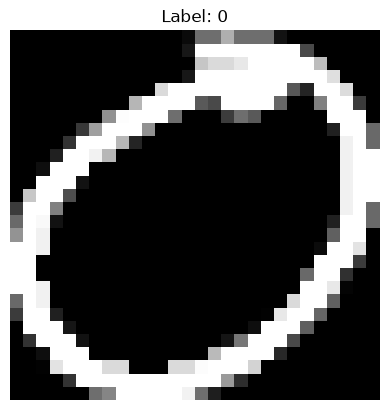

In [4]:
#| code-fold: true
#| code-summary: "Code anzeigen"


# Zahl ändern, um beliebige Schrift und Label-Kombination zu prüfen
number = 200
x_data = np.array(x_data)
print(x_data)
print(x_data.shape)
plt.imshow(x_data[number], cmap='gray')
plt.title(f"Label: {y_data[number]}")
plt.axis('off')

# Model trainieren

Nun geht es ans Training des Models.

Dazu werden die Inputdaten und Zielwerte zunächst gemeinsam zufällig gemischt, sodass die ursprüngliche Reihenfolge der Daten keine Rolle mehr spielt. Anschließend wird der Datensatz im Verhältnis 80 % zu 20 % in einen Trainings- und einen Testdatensatz aufgeteilt.

Zum Schluss werden die Daten in einem gezippten Container-Format für mehrere NumPy-Arrays (einem .npz-Array) gespeichert. .npz ist ein kompaktes, effizientes Archivformat für mehrere NumPy-Arrays und eignet sich besonders für Trainings- und Testdaten in Machine-Learning-Anwendungen.


In [5]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import os

def split_array_randomly(x_arr, y_arr, train_ratio=0.8, seed=None):
    if seed is not None:
        np.random.seed(seed)
    try: 
        x_arr.shape[0] == y_arr.shape[0]
        print('ja')
    except:
        print('shape of arrays does not match')   

            
    # Generate shuffled indices
    indices = np.random.permutation(len(x_arr))
    split_point = int(len(x_arr) * train_ratio)

    train_idx = indices[:split_point]
    test_idx = indices[split_point:]
    train_idy = indices[:split_point]
    test_idy = indices[split_point:]

    return x_arr[train_idx], x_arr[test_idx], y_arr[train_idx], y_arr[test_idx]

x_train, x_test, y_train, y_test = split_array_randomly(x_data, y_data)


print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

# Zielordner anlegen, falls er noch nicht existiert
os.makedirs('output', exist_ok=True)
np.savez('output/handwrittendigits.npz', array1=x_train, array2=x_test, array3=y_train, array4=y_test)

ja
(2744, 28, 28)
(686, 28, 28)
(2744,)
(686,)


Die Normalisierung der Bilddaten erfolgt, indem alle Pixelwerte durch 255 dividiert werden. Da Graustufenbilder Pixelintensitäten im Bereich von 0 bis 255 besitzen, werden die Werte durch diese Skalierung in den Bereich von 0 bis 1 überführt. Dadurch bleiben die relativen Helligkeitsunterschiede der Bilder erhalten, während die numerische Größenordnung der Eingabedaten deutlich reduziert wird.

Diese Normalisierung ist wichtig, weil neuronale Netze mit kleinen, vergleichbaren Zahlenwerten effizienter und stabiler lernen. Große Eingangswerte können zu instabilen Gradienten und langsamem oder fehlerhaftem Training führen. Durch die Skalierung der Pixelwerte wird der Lernprozess beschleunigt, numerische Probleme vermieden und die Konvergenz des Modells verbessert.

Das Model hat folgenden Aufbau

<figure  style="text-align: center;">
    <img src="Bilder/Skizze_NN.png" alt="NN" width = 500>
    <figcaption>Aufbau des Neuronalen Netzes zu Handschrifterkennung</figcaption>
</figure>

Es folgt einem Aufbau, der sich für die Erkennung von Zahlen bewährt hat (P.Frey, D.Slate, Letter Recognition Using Holland-Style Adaptive Classifiers, Machine Learning, 6, 161-182 (1991)).

Das mehrschichtiges Perzeptron also mit einer Eingabeschicht für 28 × 28 Pixel große Bilder, zwei versteckten Schichten mit ReLU-Aktivierungsfunktion und einer Ausgabeschicht mit zehn Neuronen und Softmax-Aktivierung definiert.

Das Modell wird mit dem Adam-Optimierer und der Verlustfunktion für mehrklassige Klassifikation kompiliert und anschließend über mehrere Epochen (epochs=100 --> 100 Epochen) trainiert, wobei ein Teil der Trainingsdaten (validation_split=0.3 --> also 30%) zur Validierung verwendet wird. Der Trainingsverlauf wird anhand von Verlust und Genauigkeit mit matplotlib visualisiert. Nach dem Training wird das Modell mit einem separaten Testdatensatz evaluiert, um die Generalisierungsleistung zu überprüfen. Abschließend werden Klassenvorhersagen berechnet und in Form einer Konfusionsmatrix dargestellt, die zeigt, wie gut die einzelnen Ziffernklassen vom Modell unterschieden werden.


Epoch 1/100


/Users/simone/Documents/FH/Vorlesungen/KI/KI-Vorlesung/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 - 1s - 14ms/step - accuracy: 0.6479 - loss: 0.0479 - val_accuracy: 0.8677 - val_loss: 0.0209
Epoch 2/100
60/60 - 0s - 1ms/step - accuracy: 0.9120 - loss: 0.0151 - val_accuracy: 0.9138 - val_loss: 0.0137
Epoch 3/100
60/60 - 0s - 1ms/step - accuracy: 0.9484 - loss: 0.0090 - val_accuracy: 0.9308 - val_loss: 0.0112
Epoch 4/100
60/60 - 0s - 1ms/step - accuracy: 0.9729 - loss: 0.0054 - val_accuracy: 0.9296 - val_loss: 0.0103
Epoch 5/100
60/60 - 0s - 1ms/step - accuracy: 0.9750 - loss: 0.0045 - val_accuracy: 0.9381 - val_loss: 0.0093
Epoch 6/100
60/60 - 0s - 1ms/step - accuracy: 0.9854 - loss: 0.0027 - val_accuracy: 0.9466 - val_loss: 0.0090
Epoch 7/100
60/60 - 0s - 1ms/step - accuracy: 0.9901 - loss: 0.0021 - val_accuracy: 0.9393 - val_loss: 0.0090
Epoch 8/100
60/60 - 0s - 1ms/step - accuracy: 0.9932 - loss: 0.0015 - val_accuracy: 0.9320 - val_loss: 0.0090
Epoch 9/100
60/60 - 0s - 1ms/step - accuracy: 0.9943 - loss: 0.0012 - val_accuracy: 0.9405 - val_loss: 0.0084
Epoch 10/100
60/60 - 

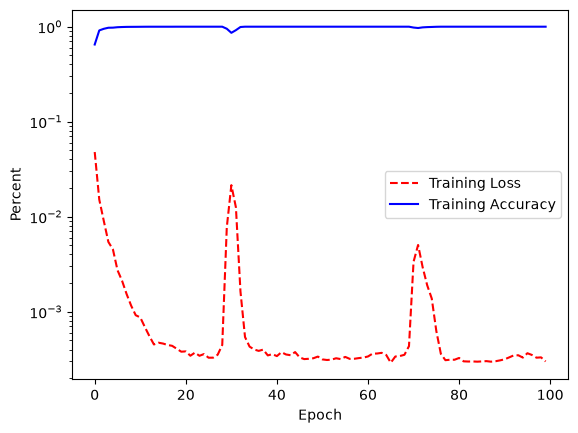

In [6]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import tensorflow as tf
import pandas as pd

# Normalize the pixel values by dividing each pixel by 255 
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build the 4-layer neural network
model = tf.keras.models.Sequential([
tf.keras.layers.Flatten(input_shape=(28, 28)),  # 28x28 Pixel in Vektor konvertieren
tf.keras.layers.Dense(128, activation='relu'),  # Fully Connected Layer
tf.keras.layers.Dense(60, activation='relu'),   # Fully Connected Layer
tf.keras.layers.Dense(10, activation='softmax') # Fully Connected Layer
])

# Compile the model and set optimizer, loss function, and metrics
# Sollten wir hier für loss einfach MSE verwenden (weil wir es bisher auch gemacht haben?)
# nur für mse
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
#model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Finally, train or fit the model (with reduced output)
trained_model = model.fit(x_train, y_train, validation_split=0.3, epochs=100, verbose=2)

# Visualize loss and accuracy history
# log darstellen
plt.plot(trained_model.history['loss'], 'r--')
plt.plot(trained_model.history['accuracy'], 'b-')
plt.legend(['Training Loss', 'Training Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Percent')
plt.yscale('log')

# Evaluate the result using the test set
evalResult = model.evaluate(x_test, y_test, verbose=1)
print("Evaluation", evalResult)
predicted = model.predict(x_test)
predicted_df = pd.DataFrame(predicted)
print("Probabilities of all classes predicted from the model:")
print(predicted_df.head(10))
print("Predicted class based on the highest probability:")
predicted_df.idxmax(axis=1)

print("===Confusion Matrix==")
#confusion = tf.math.confusion_matrix(y_test, np.argmax(predicted, axis=1), num_classes=10)
# falls mse
confusion = tf.math.confusion_matrix(np.argmax(y_test, axis=1),np.argmax(predicted, axis=1),num_classes=10)
tf.print(confusion)
tensor_values = confusion.numpy()
confusion_df = pd.DataFrame(tensor_values)
print(confusion_df)


Die Grafik zeigt den Trainingsverlauf des neuronalen Netzes über die Epochen und stellt dar, wie sich Verlustfunktion und Klassifikationsgenauigkeit während des Lernprozesses entwickeln. Auf der x-Achse ist die Anzahl der Trainingsdurchläufe (Epochen) abgetragen, während die y-Achse den Wert der jeweiligen Kenngröße in logarithmischer Skalierung darstellt.

Die rote, gestrichelte Kurve repräsentiert den Training Loss, also den Fehler des Modells auf den Trainingsdaten. Zu Beginn des Trainings ist der Fehler noch hoch, nimmt jedoch bereits nach wenigen Epochen stark ab. Im weiteren Verlauf sinkt der Loss kontinuierlich weiter und nähert sich sehr kleinen Werten an. Dies zeigt, dass das Modell die Trainingsdaten zunehmend besser approximiert und die Vorhersagen immer genauer werden.

Die blaue, durchgezogene Kurve zeigt die Training Accuracy, also den Anteil korrekt klassifizierter Trainingsbeispiele. Bereits nach wenigen Epochen steigt die Genauigkeit stark an und erreicht nahezu 100 %. Anschließend bleibt sie über den restlichen Trainingsverlauf hinweg auf einem konstant hohen Niveau, was darauf hinweist, dass das Modell die Trainingsdaten sehr zuverlässig erkennt.

<figure  style="text-align: center;">
    <img src="Bilder/ConfusionMatrix_Numbers.png" alt="Konfusionsmatrix" width = 500>
    <figcaption>Konfusionsmatrix des trainierten Models zur Erkennung von Handgeschriebenen Zahlen.</figcaption>
</figure>

Die Konfusionsmatrix gibt einen detaillierten Überblick darüber, wie gut das neuronale Netz die handgeschriebenen Ziffern im Testdatensatz erkennt. Dabei entsprechen die Zeilen den tatsächlichen Ziffernklassen (Ground Truth), während die Spalten die vom Modell vorhergesagten Klassen darstellen. Jeder Eintrag in der Matrix beschreibt, wie oft eine Ziffer einer bestimmten Klasse als eine andere – oder als die richtige – Klasse klassifiziert wurde.

Die Werte auf der Hauptdiagonalen der Matrix stehen für korrekt erkannte Ziffern. Diese Diagonale dominiert deutlich, was zeigt, dass das Modell den Großteil der Testdaten richtig klassifiziert. So wurden beispielsweise alle vorhandenen Nullen korrekt als „0“ erkannt, und auch die meisten anderen Ziffern wie Einsen, Zweien, Siebenen oder Neunen wurden jeweils über 60-mal korrekt klassifiziert. Dies weist auf eine insgesamt sehr hohe Erkennungsgenauigkeit des Modells hin.

Die **Einträge außerhalb der Diagonalen** kennzeichnen Fehlklassifikationen und machen sichtbar, bei welchen Ziffern das Modell Schwierigkeiten hat. So wurden einige Zweien fälschlicherweise als Achten erkannt, was auf ähnliche geschlossene oder geschwungene Formen in der Handschrift hindeuten kann. Ebenso zeigt die Matrix, dass Achten relativ häufig mit Sechsen verwechselt werden, da beide Ziffern in handgeschriebener Form ähnliche Rundungen aufweisen. Weitere, wenn auch seltene Verwechslungen treten beispielsweise zwischen Dreien und Siebenen auf, was auf ähnliche Strichführungen zurückzuführen sein kann.

Die **Zeilensummen** der Matrix geben außerdem Auskunft über die Anzahl der Testbeispiele pro Klasse. Diese sind relativ gleichmäßig verteilt, sodass keine Ziffer im Testdatensatz stark über- oder unterrepräsentiert ist. Dadurch ist die Aussagekraft der Matrix besonders hoch.

Insgesamt zeigt die Konfusionsmatrix nicht nur die hohe Gesamtleistung des neuronalen Netzes, sondern liefert auch wertvolle Informationen über die verbleibenden Fehler. Sie macht deutlich, welche Ziffern besonders zuverlässig erkannt werden und bei welchen Klassen aufgrund visueller Ähnlichkeiten noch Verbesserungen möglich sind, beispielsweise durch den Einsatz komplexerer Modelle oder zusätzlicher Trainingsdaten.


Um das trainierte Netzwerk später auch auf anderen Computern nutzen zu können, lässt es sich praktischerweise speichern. 

In [7]:
#| code-fold: true
#| code-summary: "Code anzeigen"
#| output: false

import os

print(type(x_test), x_test.shape)

#now save the trained model for later use
os.makedirs('output', exist_ok=True)
model.save("output/my_model.keras")

<class 'numpy.ndarray'> (686, 28, 28)


# Abschlussprojekt Überwachtes Lernen: Zahlenerkennung einer digitalen Waage